# Projet COMPAS — Fairness in Classification

**Group members :**
- Gauchier Alexandre
- Marfil Elouann
- Laucournet Tom
- Ostle Alexander

**Date :** April 2026  

## Part 1 — Exploration of the dataset and analysis of COMPAS biases

# A first analysis of the COMPAS dataset

## Dataset description

We will examine the ProPublica COMPAS dataset, which contains the records of all criminal defendants who were subject to COMPAS screening in Broward County, Florida, during 2013 and 2014. For each defendant, various information fields (‘features’) were gathered by ProPublica. Broadly, these fields are related to the defendant’s demographic information (e.g., gender and race), criminal history (e.g., the number of prior offenses) and administrative information about the case (e.g., the case number, arrest date). Finally, the dataset contains the risk of recidivism predicted by the COMPAS tool, and also information about whether the defendant did actually recidivate or not (ground truth label for us).

The COMPAS score uses answers to 137 questions to assign a risk score to defendants -- essentially an estimate of the likelihood of re-arrest. The actual output is two-fold: a risk rating of 1-10 and a "low", "medium", or "high" risk label.

Link to dataset: https://github.com/propublica/compas-analysis

The file we will analyze is: compas-scores-two-years.csv

Link to the ProPublica article:

https://www.propublica.org/article/machine-bias-risk-assessments-in-criminal-sentencing

Some of the code below is adapted from the Propublica github repository above, and from

https://investigate.ai/propublica-criminal-sentencing/week-5-1-machine-bias-class/

## Download the data

We first need to load the data from the ProPublica repo:
https://github.com/propublica/compas-analysis

In [1]:
%matplotlib inline

import urllib.request
import os,sys
import numpy as np
import pandas as pd

from sklearn import feature_extraction
from sklearn import preprocessing
from random import seed, shuffle

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 1234
seed(SEED)
np.random.seed(SEED)

def check_data_file(fname):
    files = os.listdir(".") # get the current directory listing
    print(f"Looking for file '{fname}' in the current directory...")

    if fname not in files:
        print(f"'{fname}' not found! Downloading from GitHub...")
        addr = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
        response = urllib.request.urlopen(addr)
        data = response.read()
        fileOut = open(fname, "wb")
        fileOut.write(data)
        fileOut.close()
        print(f"'{fname}' downloaded and saved locally.")
    else:
        print("File found in current directory.")
    
COMPAS_INPUT_FILE = "compas-scores-two-years.csv"
check_data_file(COMPAS_INPUT_FILE)  

Looking for file 'compas-scores-two-years.csv' in the current directory...
File found in current directory.


## Loading and cleaning data

The following code loads the data using pandas and cleans it according to ProPublica's cleaning: 

"
If the charge date of a defendants Compas scored crime was not within 30 days from when the person was arrested, we assume that because of data quality reasons, that we do not have the right offense.

We coded the recidivist flag -- is_recid -- to be -1 if we could not find a compas case at all.

In a similar vein, ordinary traffic offenses -- those with a c_charge_degree of 'O' -- will not result in Jail time are removed

We filtered the underlying data from Broward county to include only those rows representing people who had either recidivated in two years, or had at least two years outside of a correctional facility." 
"

Finally, it converts the data to a dictionary with np arrays, which will be useful later

In [2]:
# load the file
df = pd.read_csv(COMPAS_INPUT_FILE)
# print(df.shape)

df = df.dropna(subset=["days_b_screening_arrest"]) # dropping missing vals

df = df[
    (df.days_b_screening_arrest <= 30) &  
    (df.days_b_screening_arrest >= -30) &  
    (df.is_recid != -1) &
    (df.c_charge_degree != 'O') &
    (df.score_text != 'N/A')
]

df.reset_index(inplace=True, drop=True) # renumber the rows from 0 again
# df.shape

# Conversion to dictionary with np arrays
data = df.to_dict('list')
for k in data.keys():
    data[k] = np.array(data[k])

## Exploring the dataset

We first explore the dataset with a few pandas commands: examples of data, available features, missing values, descriptive statistics, and the number of defendants per race, age category and COMPAS risk category.

In the following, we will look mostly at African-American and Caucasian defendants (termed Black and White for short).

In [3]:
display(df.drop(columns=['name', 'first', 'last', 'dob']).head()) # examples of data (personal identifiers hidden)

,id,compas_screening_date,sex,age,age_cat,race,juv_fel_count,decile_score,juv_misd_count,juv_other_count,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,2013-08-14,Male,69,Greater than 45,Other,0,1,0,0,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,2013-01-27,Male,34,25 - 45,African-American,0,3,0,0,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,2013-04-14,Male,24,Less than 25,African-American,0,4,0,1,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,7,2013-11-30,Male,44,25 - 45,Other,0,1,0,0,...,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
4,8,2014-02-19,Male,41,25 - 45,Caucasian,0,6,0,0,...,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1


In [4]:
display(df.columns) # prints the features

Index(['id', 'name', 'first', 'last', 'compas_screening_date', 'sex', 'dob',
       'age', 'age_cat', 'race', 'juv_fel_count', 'decile_score',
       'juv_misd_count', 'juv_other_count', 'priors_count',
       'days_b_screening_arrest', 'c_jail_in', 'c_jail_out', 'c_case_number',
       'c_offense_date', 'c_arrest_date', 'c_days_from_compas',
       'c_charge_degree', 'c_charge_desc', 'is_recid', 'r_case_number',
       'r_charge_degree', 'r_days_from_arrest', 'r_offense_date',
       'r_charge_desc', 'r_jail_in', 'r_jail_out', 'violent_recid',
       'is_violent_recid', 'vr_case_number', 'vr_charge_degree',
       'vr_offense_date', 'vr_charge_desc', 'type_of_assessment',
       'decile_score.1', 'score_text', 'screening_date',
       'v_type_of_assessment', 'v_decile_score', 'v_score_text',
       'v_screening_date', 'in_custody', 'out_custody', 'priors_count.1',
       'start', 'end', 'event', 'two_year_recid'],
      dtype='str')

In [5]:
print(df.isnull().sum()) #check for missing values

id                            0
name                          0
first                         0
last                          0
compas_screening_date         0
sex                           0
dob                           0
age                           0
age_cat                       0
race                          0
juv_fel_count                 0
decile_score                  0
juv_misd_count                0
juv_other_count               0
priors_count                  0
days_b_screening_arrest       0
c_jail_in                     0
c_jail_out                    0
c_case_number                 0
c_offense_date              784
c_arrest_date              5388
c_days_from_compas            0
c_charge_degree               0
c_charge_desc                 5
is_recid                      0
r_case_number              3182
r_charge_degree            3182
r_days_from_arrest         4175
r_offense_date             3182
r_charge_desc              3228
r_jail_in                  4175
r_jail_o

In [6]:
print(df.describe()) # generates descriptive statistics (e.g., to check for outliers)

                 id          age  juv_fel_count  decile_score  juv_misd_count  \
count   6172.000000  6172.000000    6172.000000   6172.000000     6172.000000   
mean    5509.259883    34.534511       0.059300      4.418503        0.091218   
std     3171.878516    11.730938       0.463599      2.839463        0.497872   
min        1.000000    18.000000       0.000000      1.000000        0.000000   
25%     2753.750000    25.000000       0.000000      2.000000        0.000000   
50%     5521.000000    31.000000       0.000000      4.000000        0.000000   
75%     8225.250000    42.000000       0.000000      7.000000        0.000000   
max    11001.000000    96.000000      20.000000     10.000000       13.000000   

       juv_other_count  priors_count  days_b_screening_arrest  \
count      6172.000000   6172.000000              6172.000000   
mean          0.110661      3.246436                -1.740279   
std           0.470731      4.743770                 5.084709   
min       

In [7]:
print(df.race.unique()) # different races we have in the dataset

<StringArray>
[           'Other', 'African-American',        'Caucasian',
         'Hispanic',            'Asian',  'Native American']
Length: 6, dtype: str


In [8]:
print(df.age_cat.value_counts()) #number of people by age category

age_cat
25 - 45            3532
Less than 25       1347
Greater than 45    1293
Name: count, dtype: int64


In [9]:
print(df.score_text.value_counts()) #number of people by COMPAS risk category

score_text
Low       3421
Medium    1607
High      1144
Name: count, dtype: int64


In [10]:
print(df.race.value_counts())

race
African-American    3175
Caucasian           2103
Hispanic             509
Other                343
Asian                 31
Native American       11
Name: count, dtype: int64


## Basic analysis of the bias in COMPAS scores

We now look at the COMPAS scores (deciles first, then text scores) as a function of the sensitive attribute (race or gender) to observe potential differences. 

We start by plotting the histograms of decile scores for Black and White defendants.

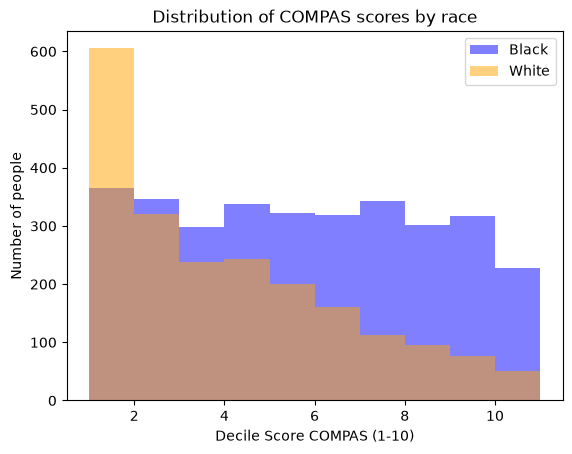

In [11]:
# Histogram of decile scores for Blacks (blue) and Whites (orange)
blacks = df[df.race == 'African-American']['decile_score']
whites = df[df.race == 'Caucasian']['decile_score']

import matplotlib.pyplot as plt

plt.hist(blacks, bins=10, range=(1,11), alpha=0.5, color='blue', label='Black')
plt.hist(whites, bins=10, range=(1,11), alpha=0.5, color='orange', label='White')

plt.xlabel('Decile Score COMPAS (1-10)')
plt.ylabel('Number of people')
plt.title('Distribution of COMPAS scores by race')
plt.legend()
plt.show()


We observe that the distribution of COMPAS scores differs significantly depending on race.  
White defendants (Caucasian) mostly receive low scores (1-2), while Black defendants (African-American) have a much more spread out distribution, with a significant number of high scores (7-10).  
This suggests that COMPAS assigns higher risk levels to Black defendants than to White defendants.

The above observation can be explained by a dependence between the race and true label.

In [12]:
# recidivism rates by race
recid_race = pd.crosstab(df.race, df.two_year_recid)
recid_race['rate'] = recid_race[1] / recid_race.sum(axis=1)
recid_race

two_year_recid,0,1,rate
race,,,
African-American,1514,1661,0.523150
Asian,23,8,0.258065
Caucasian,1281,822,0.390870
Hispanic,320,189,0.371316
Native American,6,5,0.454545
Other,219,124,0.361516


We observe that the actual recidivism rate over 2 years varies according to race: African-Americans have the highest rate (52.3%), followed by Native Americans (45.5%) and Caucasians (39.1%), which partially justifies the differences in COMPAS scores observed previously.

We now look at whether we observe a similar phenomenon on the text scores of COMPAS (low, medium, high risk).

In [13]:
# high risk rates by race
score_race = pd.crosstab(df.race, df.score_text)
score_race['High risk rate'] = score_race['High'] / score_race.sum(axis=1)
score_race

score_text,High,Low,Medium,High risk rate
race,,,,
African-American,845,1346,984,0.266142
Asian,3,24,4,0.096774
Caucasian,223,1407,473,0.106039
Hispanic,47,368,94,0.092338
Native American,4,3,4,0.363636
Other,22,273,48,0.064140


Africans-Americans are classified as 'High risk' by COMPAS in 26.6% of cases, compared to only 10.6% for Caucasians, which is 2.5 times more.  
This overrepresentation of Black people in the 'High risk' category suggests that the COMPAS is harsher towards them.  
We will investigate whether this difference is justified by actual recidivism in the next section by calculating false positives and falses negatives by race.

### Fairness metrics for the COMPAS scores

We do not have the actual scores that are used to compute test scores Low-Med-High; hence we cannot investigate directly the calibration. However, we can use the decile score as a proxy, and we can investigate PPV. 

Let us first plot the probability of recidivism by decile score. We observe that it is not very far from a diagonale.

<Axes: xlabel='decile_score'>

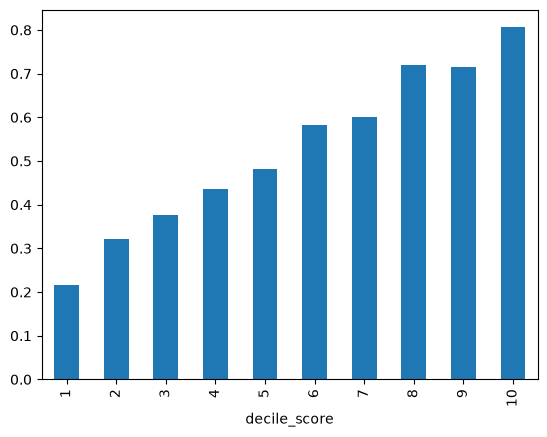

In [14]:
# probability of recidivism by decile
df.groupby(df.decile_score).mean(numeric_only=True)['two_year_recid'].plot(kind='bar')

It is observed that the actual recidivism rate gradually increases with the COMPAS score, which indicates that the model is generally well calibrated.
A high score does indeed correspond to a higher probability of recidivism.

We now plot the same graph with separate bars for Black and White defendants.

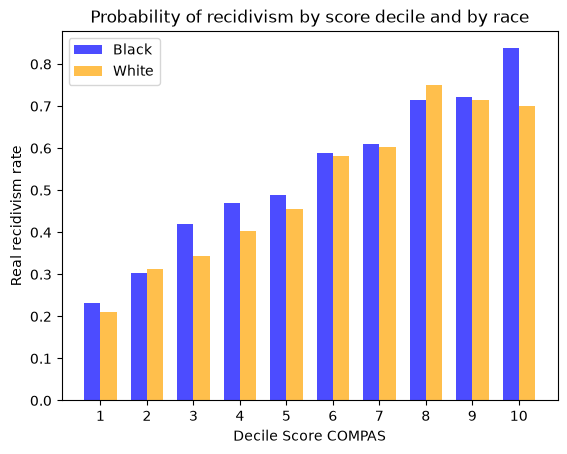

In [15]:
# probability of recidivism by decile and race
blacks = df[df.race == 'African-American']
whites = df[df.race == 'Caucasian']

recid_blacks = blacks.groupby('decile_score').mean(numeric_only=True)['two_year_recid']
recid_whites = whites.groupby('decile_score').mean(numeric_only=True)['two_year_recid']

x = np.arange(1, 11)
width = 0.35

plt.bar(x - width/2, recid_blacks, width=width, label='Black', color='blue', alpha=0.7)
plt.bar(x + width/2, recid_whites, width=width, label='White', color='orange', alpha=0.7)

plt.xlabel('Decile Score COMPAS')
plt.ylabel('Real recidivism rate')
plt.title('Probability of recidivism by score decile and by race')
plt.xticks(x)
plt.legend()
plt.show()


At equal scores, the real recidivism rates for Black and White are very similar, which indicates that the COMPAS is generally well calibrated for both groups.  
However, this does not mean that the COMPAS is fair. As previously observed, Black people receive disproportionately higher scores, which results in more false positives for this group.

To further analyze the COMPAS score as a classifier, we transform it into a binary outcome by splitting "low" (class 0) from "medium or high" risk (class 1). We can then compute standard quantities such as the confusion matrix or PPV.

In [16]:
# COMPAS recidivism confusion matrix
df['guessed_recid'] = df.score_text != 'Low'
df['actual_recid'] = df.two_year_recid == 1
cm = pd.crosstab(df.actual_recid, df.guessed_recid)
cm # for "confusion matrix"

guessed_recid,False,True
actual_recid,,
False,2345,1018
True,1076,1733


The COMPAS confusion matrix shows an overall accuracy of about 66%.  
There are 1,018 false positives (people classified as 'at risk' who have not reoffended).  
And 1,076 false negatives (people classified as 'low risk' who have nevertheless reoffended).  
The number of false positives and false negatives is relatively similar at the global level, but we will see in the next section that this distribution is very unequal depending on race.

We finally compute the accuracy, PPV, FPR and FNR of the COMPAS classifier for Black and White defendants.

In [17]:
# cm is a confusion matrix. The rows are guessed, the columns are actual 
def print_ppv_fpv(cm):
    # the indices here are [col][row] or [actual][guessed]
    TN = cm[False][False]   
    TP = cm[True][True]
    FN = cm[True][False]
    FP = cm[False][True]
    print('Accuracy: ', (TP + TN) / (TP + TN + FP + FN))
    print('PPV: ', TP / (TP + FP))
    print('FPR: ', FP / (FP + TN))
    print('FNR: ', FN / (FN + TP))
    print()


def print_metrics(guessed, actual):
    cm = pd.crosstab(guessed, actual, rownames=['guessed'], colnames=['actual'])
    print(cm)
    print()
    print_ppv_fpv(cm)   
    
print('White')
subset = df[df.race == 'Caucasian']
print_metrics(subset.guessed_recid, subset.actual_recid)

print('Black')
subset = df[df.race == 'African-American']
print_metrics(subset.guessed_recid, subset.actual_recid)

White
actual   False  True 
guessed              
False      999    408
True       282    414

Accuracy:  0.6718972895863052
PPV:  0.5948275862068966
FPR:  0.22014051522248243
FNR:  0.49635036496350365

Black
actual   False  True 
guessed              
False      873    473
True       641   1188

Accuracy:  0.6491338582677165
PPV:  0.6495352651722253
FPR:  0.4233817701453104
FNR:  0.2847682119205298



The following table summarizes the key fairness metrics for COMPAS, comparing White and Black people :

| Metrics | White | Black | Gap | Interpretation |
|---|---|---|---|---|
| **Accuracy** | 67.2% | 65.0% | 2.2 pts | Similar for both groups |
| **PPV** | 59.5% | 64.9% | 5.4 pts | Similar → COMPAS well calibrated |
| **FPR** | 22.0% | 42.3% | **20.3 pts** | Black defendants who did not reoffend are about twice as often labeled "at risk" |
| **FNR** | 49.6% | 28.5% | **21.1 pts** | White defendants who did reoffend are about twice as often missed |

Conclusion: the False Positive Rate is substantially higher for Black defendants, but the PPV is similar for Black and White defendants. That is, the COMPAS score satisfies sufficiency, but not separation.

## Training a classifier from the ground truth label

We now train a classifier (a simple logistic regression) on the label two_year_recid. We work on a subset of features: ["age_cat", "race", "sex", "priors_count", "c_charge_degree"]. 


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from collections import defaultdict

FEATURES_CLASSIFICATION = ["age_cat", "race", "sex", "priors_count", "c_charge_degree"] #features to be used for classification
CONT_VARIABLES = ["priors_count"] # continuous features, will need to be handled separately from categorical features, categorical features will be encoded using one-hot
CLASS_FEATURE = "two_year_recid" # the decision variable
SENSITIVE_ATTRS = ["race"]


y = data[CLASS_FEATURE]
X = np.array([]).reshape(len(y), 0) # empty array with num rows same as num examples, will hstack the features to it
x_control = defaultdict(list)

for attr in FEATURES_CLASSIFICATION:
    vals = data[attr]
    if attr in CONT_VARIABLES:
        vals = [float(v) for v in vals]
        vals = preprocessing.scale(vals) # 0 mean and 1 variance  
        vals = np.reshape(vals, (len(y), -1)) # convert from 1-d arr to a 2-d arr with one col

    else: # this encodes categorical variables in a numerical way -- there are other ways to do it
        enc = preprocessing.LabelBinarizer()
        enc.fit(vals)
        vals = enc.transform(vals)

    # add to learnable features
    X = np.hstack((X, vals))

    
# the following is a very dirty way to keep track of the race after the train_test_split    
ind = data["race"]=="African-American"
X_b = X[ind] 
y_b = y[ind]
ind = data["race"]=="Caucasian"
X_w = X[ind]        
y_w = y[ind]
ind = [data["race"][i]!="Caucasian" and data["race"][i]!="African-American" for i in range(len(y))]
X_n = X[ind]        
y_n = y[ind]
    
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_b, y_b, test_size=0.3, random_state=1234)
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(X_w, y_w, test_size=0.3, random_state=5678)
X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(X_n, y_n, test_size=0.3, random_state=9012)

X_train = np.vstack((X_train_b, X_train_w, X_train_n))
y_train = np.hstack((y_train_b, y_train_w, y_train_n))
X_test = np.vstack((X_test_b, X_test_w, X_test_n))
y_test = np.hstack((y_test_b, y_test_w, y_test_n))



model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

We can then compute the model accuracy. Compare to the COMPAS accuracy. 

In [19]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
print('Accuracy:', accuracy_score(y_test, y_pred))

Accuracy: 0.6540744738262277


The logistic regression reaches an accuracy of 65.4%; very close to that of COMPAS (66.2%), using only 5 simple features against 137 for COMPAS.  
This suggests that the additional information used by the COMPAS does not bring a significant performance gain.

We can also plot the ROC curve for the model on the global population. 

The ROC (Receiver Operating Characteristic) curve represents the tradeoff between the true positive rate (TPR) and the false positive rate (FPR) for different classification thresholds. The closer the curve is to the upper left corner, the better the model, a curve on the diagonal would correspond to a random preference.

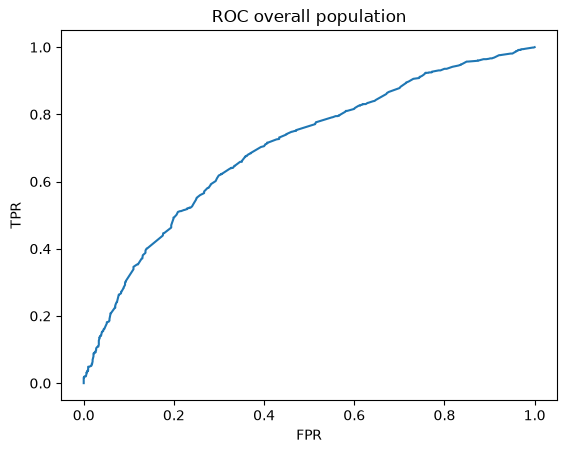

In [20]:
from sklearn.metrics import roc_curve
from matplotlib import pyplot as plt

scores = model.predict_proba(X_test)
fpr, tpr, thresholds = roc_curve(y_test, scores[:,1])

plt.plot(fpr, tpr)

plt.title('ROC overall population')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()


In [21]:
from sklearn.metrics import roc_auc_score
print('AUC:', roc_auc_score(y_test, scores[:,1]))

AUC: 0.7014143456740773


The ROC curve of our logistic regression is well above the diagonal and reaches an AUC of about 0.70, which confirms that the model has a satisfying predictive power despite using only 5 features.

We now plot the ROC curves for Black and White defendants separately, on the same plot.

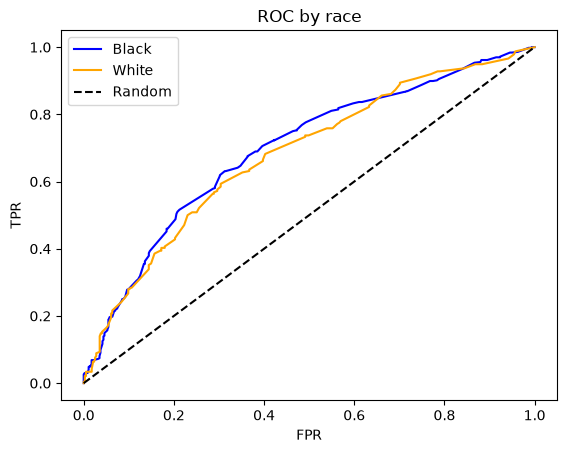

In [22]:
scores_b = model.predict_proba(X_test_b)
scores_w = model.predict_proba(X_test_w)

fpr_b, tpr_b, _ = roc_curve(y_test_b, scores_b[:,1])
fpr_w, tpr_w, _ = roc_curve(y_test_w, scores_w[:,1])

plt.plot(fpr_b, tpr_b, color='blue', label='Black')
plt.plot(fpr_w, tpr_w, color='orange', label='White')

plt.plot([0,1], [0,1], color='black', linestyle='--', label='Random')

plt.title('ROC by race')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.show()

In [23]:
auc_b = roc_auc_score(y_test_b, scores_b[:,1])
auc_w = roc_auc_score(y_test_w, scores_w[:,1])

print('AUC Black people:', auc_b)
print('AUC White people:', auc_w)

AUC Black people: 0.6951057033952143
AUC White people: 0.6793338339412143


Race-separated ROC curves show that the model performs similarly for Black people (AUC = 0.695) and White people (AUC = 0.679). The slight difference is probably explained by the overrepresentation of Black people in the dataset, which allows the model to better learn patterns.  
Unlike the COMPAS, our model does not seem to discriminate significantly between the two groups in terms of predictive power.

We can finally check the fairness of this simple logistic regression, when choosing an arbitrary threshold common to the two groups. 

We compute the predictions with a common threshold of 0.5, then compare the accuracy, PPV, FPR and FNR between Black and White defendants.

In [24]:
threshold_common = 0.5

# Predictions with common threshold
y_pred_b = (scores_b[:,1] >= threshold_common).astype(bool)
y_pred_w = (scores_w[:,1] >= threshold_common).astype(bool)

print('White')
print_metrics(y_pred_w, y_test_w.astype(bool))

print('Black')
print_metrics(y_pred_b, y_test_b.astype(bool))

White
actual   False  True 
guessed              
False      324    141
True        71     95

Accuracy:  0.6640253565768621
PPV:  0.572289156626506
FPR:  0.17974683544303796
FNR:  0.597457627118644

Black
actual   False  True 
guessed              
False      298    175
True       159    321

Accuracy:  0.6495278069254984
PPV:  0.66875
FPR:  0.3479212253829322
FNR:  0.3528225806451613



| Metrics | White | Black | Gap | Interpretation |
|---|---|---|---|---|
| **Accuracy** | 66.4% | 64.9% | 1.5 pts | Similar for both groups |
| **PPV** | 57.2% | 66.9% | 9.7 pts | Slightly higher for Black defendants |
| **FPR** | 18.0% | 34.8% | **16.8 pts** | Black defendants who did not reoffend are about twice as often labeled "at risk" |
| **FNR** | 59.7% | 35.3% | **24.4 pts** | White defendants who did reoffend are 1.7x more often missed |

With a common threshold of 0.5, we observe that the FPR of Black defendants (34.8%) is 1.9x higher than that of White defendants (18.0%): Black defendants who did not reoffend are much more often wrongly classified as recidivists.  
Moreover, the FNR of White defendants (59.7%) is 1.7x higher than that of Black defendants (35.3%), which means that White defendants who did reoffend are much more often missed by the model.

Finally, we can also investigate the calibration more finely using the calibration module from sklearn. 

We first plot the calibration curve for the whole population.

The calibration curve represents the correspondence between the probabilities predicted by the model and the real observed probabilities.  
The closer the curve is to the diagonal, the better the model.

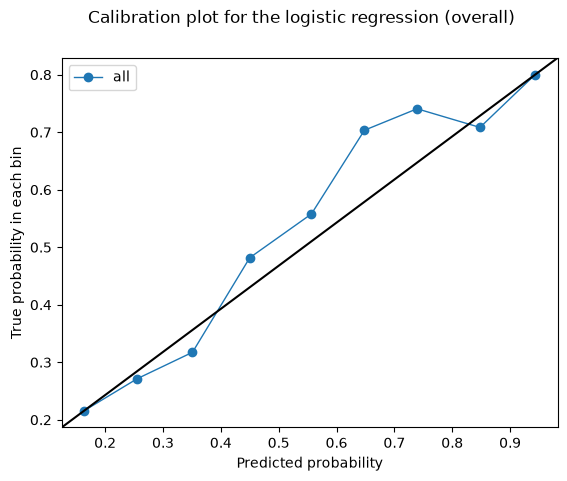

In [25]:
from sklearn.calibration import calibration_curve
import matplotlib.lines as mlines
import matplotlib.transforms as mtransforms


scores = model.predict_proba(X_test)
prob_true, prob_pred = calibration_curve(y_test, scores[:,1], n_bins=10)

fig, ax = plt.subplots()
# only this line is calibration curves
plt.plot(prob_pred,prob_true, marker='o', linewidth=1, label='all')

# reference line, legends, and axis labels
line = mlines.Line2D([0, 1], [0, 1], color='black')
transform = ax.transAxes
line.set_transform(transform)
ax.add_line(line)
fig.suptitle('Calibration plot for the logistic regression (overall)')
ax.set_xlabel('Predicted probability')
ax.set_ylabel('True probability in each bin')
plt.legend()
plt.show()

The global calibration curve follows approximately the diagonal, which indicates that our model is well calibrated.  
However, there are some discrepancies, including a slight overestimate of risk for low probabilities and a slight underestimate for average probabilities.

We then plot the calibration curves for Black and White defendants separately.

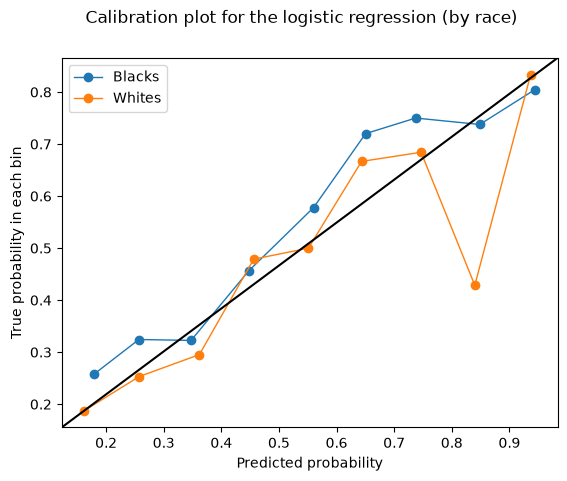

In [26]:
scores_b = model.predict_proba(X_test_b)
prob_true_b, prob_pred_b = calibration_curve(y_test_b, scores_b[:,1], n_bins=10)

scores_w = model.predict_proba(X_test_w)
prob_true_w, prob_pred_w = calibration_curve(y_test_w, scores_w[:,1], n_bins=10)

fig, ax = plt.subplots()
# only this line is calibration curves
plt.plot(prob_pred_b,prob_true_b, marker='o', linewidth=1, label='Blacks')
plt.plot(prob_pred_w,prob_true_w, marker='o', linewidth=1, label='Whites')

# reference line, legends, and axis labels
line = mlines.Line2D([0, 1], [0, 1], color='black')
transform = ax.transAxes
line.set_transform(transform)
ax.add_line(line)
fig.suptitle('Calibration plot for the logistic regression (by race)')
ax.set_xlabel('Predicted probability')
ax.set_ylabel('True probability in each bin')
plt.legend()
plt.show()

The calibration curves separated by race show that the model is generally well calibrated for both groups, the curves follow approximately the diagonal.  
However, we observe greater instability for White people, especially for high probabilities, which is explained by their lower representation in the dataset.  
We can conclude that our model satisfies sufficiency, but does not respect separation.

## Part 2 — Standard classifiers and fairness analysis

### 2.1 Features choices

We use the following 5 features:

| Feature | Description | Justification |
|---|---|---|
| `age_cat` | Age | Correlated with recidivism—young people recidivate more |
| `race` | Race | Sensitive attribute—we are testing its impact |
| `sex` | Gender | Correlated with recidivism—men recidivate more |
| `priors_count` | Number of past convictions | Most Predictive Feature |
| `c_charge_degree` | Seriousness of the offence | Danger indicator |

We exclude administrative features (dates, file numbers) because they have no predictive value. We also exclude `decile_score` and `score_text` because these are the predictions of the COMPAS itself—including them would be like copying the COMPAS.

### 2.2 Training of several classifiers

#### 2.2.1 Standard classifiers with baseline features (5 features)

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, roc_auc_score

# Definition of classifiers
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=SEED),
    'Random Forest': RandomForestClassifier(random_state=SEED),
    'Gradient Boosting': GradientBoostingClassifier(random_state=SEED),
    'SVM': SVC(probability=True, random_state=SEED),
    'KNN': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB()
}

# Training and evaluation
results = []
for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    scores = clf.predict_proba(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, scores[:,1])
    
    results.append({
        'Classifiers': name,
        'Accuracy': round(acc, 3),
        'AUC': round(auc, 3)
    })

df_results = pd.DataFrame(results).sort_values('AUC', ascending=False)
print(df_results.to_string(index=False))

        Classifiers  Accuracy   AUC
  Gradient Boosting     0.666 0.710
                SVM     0.665 0.707
Logistic Regression     0.654 0.701
      Random Forest     0.645 0.692
      Decision Tree     0.648 0.685
        Naive Bayes     0.626 0.660
                KNN     0.641 0.659


The performances of the different classifiers are globally similar, with accuracies between 62% and 67% and AUC between 0.652 and 0.710.  
Gradient Boosting has the best performance (AUC = 0.710), followed by SVM (0.707) and Logistic Regression (0.701).  
These results are comparable to those of the COMPAS (66.2%) using only 5 simple features.  

#### 2.2.2 Feature exploration — searching for the best combination

In this section, our goal is to find the most predictive feature combination, focusing purely on performance (AUC) without considering fairness constraints. We test 10 different feature combinations and select the best one.

In [28]:
# Testing many different feature combinations — performance only
feature_sets = {
    '5 features (baseline)': {
        'features': ["age_cat", "race", "sex", "priors_count", "c_charge_degree"],
        'cont': ["priors_count"]
    },
    '5 features (no race)': {
        'features': ["age_cat", "sex", "priors_count", "c_charge_degree"],
        'cont': ["priors_count"]
    },
    '8 features (age + juvenile + race)': {
        'features': ["age", "race", "sex", "priors_count", "c_charge_degree",
                     "juv_fel_count", "juv_misd_count", "juv_other_count"],
        'cont': ["age", "priors_count", "juv_fel_count", "juv_misd_count", "juv_other_count"]
    },
    '7 features (no race)': {
        'features': ["age", "sex", "priors_count", "c_charge_degree",
                     "juv_fel_count", "juv_misd_count", "juv_other_count"],
        'cont': ["age", "priors_count", "juv_fel_count", "juv_misd_count", "juv_other_count"]
    },
    'Criminal history only': {
        'features': ["priors_count", "juv_fel_count", "juv_misd_count",
                     "juv_other_count", "c_charge_degree"],
        'cont': ["priors_count", "juv_fel_count", "juv_misd_count", "juv_other_count"]
    },
    'Demographics only': {
        'features': ["age", "sex", "race"],
        'cont': ["age"]
    },
    'Demographics only (no race)': {
        'features': ["age", "sex"],
        'cont': ["age"]
    },
    'Age + criminal history': {
        'features': ["age", "priors_count", "juv_fel_count", "juv_misd_count",
                     "juv_other_count"],
        'cont': ["age", "priors_count", "juv_fel_count", "juv_misd_count", "juv_other_count"]
    },
    'Full (no race)': {
        'features': ["age", "sex", "priors_count", "c_charge_degree",
                     "juv_fel_count", "juv_misd_count", "juv_other_count",
                     "days_b_screening_arrest"],
        'cont': ["age", "priors_count", "juv_fel_count", "juv_misd_count",
                 "juv_other_count", "days_b_screening_arrest"]
    },
    'Full (with race)': {
        'features': ["age", "race", "sex", "priors_count", "c_charge_degree",
                     "juv_fel_count", "juv_misd_count", "juv_other_count",
                     "days_b_screening_arrest"],
        'cont': ["age", "priors_count", "juv_fel_count", "juv_misd_count",
                 "juv_other_count", "days_b_screening_arrest"]
    }
}

best_auc = 0
best_set = None
all_results = []

for set_name, config in feature_sets.items():
    y_fs = data[CLASS_FEATURE]
    X_fs = np.array([]).reshape(len(y_fs), 0)
    
    for attr in config['features']:
        vals = data[attr]
        if attr in config['cont']:
            vals = [float(v) for v in vals]
            vals = preprocessing.scale(vals)
            vals = np.reshape(vals, (len(y_fs), -1))
        else:
            enc = preprocessing.LabelBinarizer()
            enc.fit(vals)
            vals = enc.transform(vals)
        X_fs = np.hstack((X_fs, vals))
    
    X_train_fs, X_test_fs, y_train_fs, y_test_fs = train_test_split(
        X_fs, y_fs, test_size=0.3, random_state=1234)
    
    clf_fs = GradientBoostingClassifier(random_state=SEED)
    clf_fs.fit(X_train_fs, y_train_fs)
    scores_fs = clf_fs.predict_proba(X_test_fs)
    
    acc = accuracy_score(y_test_fs, clf_fs.predict(X_test_fs))
    auc = roc_auc_score(y_test_fs, scores_fs[:,1])
    
    all_results.append({
        'Feature set': set_name,
        'Accuracy': round(acc, 3),
        'AUC': round(auc, 3)
    })
    
    if auc > best_auc:
        best_auc = auc
        best_set = set_name

df_features = pd.DataFrame(all_results).sort_values('AUC', ascending=False)
print(df_features.to_string(index=False))
print(f"\nBest feature set: {best_set} (AUC = {best_auc:.3f})")

                       Feature set  Accuracy   AUC
                    Full (no race)     0.690 0.730
              7 features (no race)     0.683 0.728
            Age + criminal history     0.681 0.725
                  Full (with race)     0.685 0.724
8 features (age + juvenile + race)     0.674 0.720
             5 features (baseline)     0.664 0.711
              5 features (no race)     0.666 0.711
             Criminal history only     0.652 0.690
                 Demographics only     0.607 0.626
       Demographics only (no race)     0.596 0.615

Best feature set: Full (no race) (AUC = 0.730)


The best feature set is **Full (no race)** (AUC = 0.730), closely followed by **7 features (no race)** (AUC = 0.728). As the difference is negligible, we keep the 7-feature set, which is simpler and does not rely on the administrative variable `days_b_screening_arrest`. It improves on the 5-feature baseline (AUC = 0.711) and slightly outperforms COMPAS in accuracy (68.3% vs ~66%).

Removing race from the feature set slightly improves the AUC (0.720 → 0.728 for the 7/8-feature sets, 0.724 → 0.730 for the full sets), confirming that race adds no predictive value beyond the other features. The most predictive features are the criminal history variables (priors_count, juvenile counts): demographics alone only reach an AUC of 0.626.

*Note: an earlier version of this analysis also used `is_violent_recid`. This variable records violent reoffending that happened **after** the COMPAS screening, so it is not available at decision time and is strongly correlated with the target. It caused data leakage and was removed.*


### 2.3 Evaluation of classifiers fairness

**Our fairness definition**

Several fairness notions can be considered. Sufficiency requires that, among people labeled "at risk", the same proportion actually reoffends across groups. Independence requires that the rate of "at risk" predictions be equal across groups.

In this project, we focus primarily on **separation**: the FPR and FNR should be equal across racial groups, as wrongly classifying people who would not reoffend as "at risk" has serious consequences in a judicial context.

#### 2.3.1 Simpler classifier

In [29]:
def compute_fairness(clf, X_b, y_b, X_w, y_w, threshold=0.5):
    """Calculates FPR, FNR, PPV and Independence for blacks and whites."""
    
    scores_b = clf.predict_proba(X_b)[:,1]
    scores_w = clf.predict_proba(X_w)[:,1]
    
    y_pred_b = (scores_b >= threshold).astype(int)
    y_pred_w = (scores_w >= threshold).astype(int)
    
    # Blacks
    tn_b = ((y_pred_b == 0) & (y_b == 0)).sum()
    tp_b = ((y_pred_b == 1) & (y_b == 1)).sum()
    fp_b = ((y_pred_b == 1) & (y_b == 0)).sum()
    fn_b = ((y_pred_b == 0) & (y_b == 1)).sum()
    
    # Whites
    tn_w = ((y_pred_w == 0) & (y_w == 0)).sum()
    tp_w = ((y_pred_w == 1) & (y_w == 1)).sum()
    fp_w = ((y_pred_w == 1) & (y_w == 0)).sum()
    fn_w = ((y_pred_w == 0) & (y_w == 1)).sum()
    
    fpr_b = fp_b / (fp_b + tn_b)
    fnr_b = fn_b / (fn_b + tp_b)
    fpr_w = fp_w / (fp_w + tn_w)
    fnr_w = fn_w / (fn_w + tp_w)
    ppv_b = tp_b / (tp_b + fp_b) if (tp_b + fp_b) > 0 else 0
    ppv_w = tp_w / (tp_w + fp_w) if (tp_w + fp_w) > 0 else 0
    
    # Independence — rate of positive predictions
    ind_b = y_pred_b.mean()
    ind_w = y_pred_w.mean()
    
    return {
        'FPR Blacks': round(fpr_b, 3),
        'FPR Whites': round(fpr_w, 3),
        'FPR Gap': round(fpr_b - fpr_w, 3),
        'FNR Blacks': round(fnr_b, 3),
        'FNR Whites': round(fnr_w, 3),
        'FNR Gap': round(fnr_b - fnr_w, 3),
        'PPV Blacks': round(ppv_b, 3),
        'PPV Whites': round(ppv_w, 3),
        'PPV Gap': round(ppv_b - ppv_w, 3),
        'Ind. Blacks': round(ind_b, 3),
        'Ind. Whites': round(ind_w, 3),
        'Ind. Gap': round(ind_b - ind_w, 3),
    }


In [30]:
# Evaluation for each classifier
fairness_results = []
for name, clf in classifiers.items():
    metrics = compute_fairness(clf, X_test_b, y_test_b, X_test_w, y_test_w)
    metrics['Classifier'] = name
    fairness_results.append(metrics)

# Adding COMPAS
compas_metrics = {
    'Classifier': 'COMPAS',
    'FPR Blacks': 0.423,
    'FPR Whites': 0.220,
    'FPR Gap': 0.203,
    'FNR Blacks': 0.285,
    'FNR Whites': 0.497,
    'FNR Gap': -0.212,
    'PPV Blacks': 0.649,
    'PPV Whites': 0.595,
    'PPV Gap': 0.054,
    'Ind. Blacks': 0.516,  # (845+984)/3175 from score_race
    'Ind. Whites': 0.331,  # (223+473)/2103
    'Ind. Gap': 0.185,
}
fairness_results.append(compas_metrics)

df_fairness = pd.DataFrame(fairness_results).set_index('Classifier')

# Table 1 — Raw metrics
print("=== Fairness metrics by group ===")
display(df_fairness[['FPR Blacks', 'FPR Whites', 'FNR Blacks', 'FNR Whites', 
                      'PPV Blacks', 'PPV Whites', 'Ind. Blacks', 'Ind. Whites']])

# Table 2 — Gaps only
print("\n=== Fairness gaps ===")
display(df_fairness[['FPR Gap', 'FNR Gap', 'PPV Gap', 'Ind. Gap']])

=== Fairness metrics by group ===


,FPR Blacks,FPR Whites,FNR Blacks,FNR Whites,PPV Blacks,PPV Whites,Ind. Blacks,Ind. Whites
Classifier,,,,,,,,
Logistic Regression,0.348,0.180,0.353,0.597,0.669,0.572,0.504,0.263
Decision Tree,0.350,0.190,0.349,0.602,0.669,0.556,0.507,0.268
Random Forest,0.339,0.172,0.361,0.640,0.672,0.556,0.495,0.242
Gradient Boosting,0.389,0.185,0.288,0.564,0.665,0.585,0.557,0.279
SVM,0.370,0.132,0.325,0.648,0.665,0.615,0.529,0.214
KNN,0.479,0.185,0.242,0.644,0.632,0.535,0.624,0.249
Naive Bayes,0.648,0.147,0.167,0.640,0.583,0.594,0.744,0.227
COMPAS,0.423,0.220,0.285,0.497,0.649,0.595,0.516,0.331



=== Fairness gaps ===


,FPR Gap,FNR Gap,PPV Gap,Ind. Gap
Classifier,,,,
Logistic Regression,0.168,-0.245,0.096,0.241
Decision Tree,0.160,-0.253,0.113,0.239
Random Forest,0.167,-0.279,0.116,0.253
Gradient Boosting,0.205,-0.275,0.080,0.278
SVM,0.238,-0.324,0.050,0.315
KNN,0.294,-0.402,0.097,0.376
Naive Bayes,0.501,-0.472,-0.012,0.517
COMPAS,0.203,-0.212,0.054,0.185


None of the classifiers satisfy the three fairness notions. All models show significant FPR, FNR and Independence gaps between Black and White people. The Decision Tree has the smallest FPR gap (16.0 pts) while Naive Bayes is the most biased (50.1 pts). Interestingly, the PPV gap is small for most classifiers (~0.05-0.11), suggesting that sufficiency is partially satisfied, similarly to COMPAS.  
These results confirm that standard classifiers inevitably reproduce the biases present in the data

#### 2.3.2 Optimized classifier (best feature combination)

In [31]:
# Build X with best feature set (7 features, no race)
FEATURES_BEST = ["age", "sex", "priors_count", "c_charge_degree",
                 "juv_fel_count", "juv_misd_count", "juv_other_count"]
CONT_BEST = ["age", "priors_count", "juv_fel_count", "juv_misd_count", "juv_other_count"]

y_best = data[CLASS_FEATURE]
X_best = np.array([]).reshape(len(y_best), 0)

for attr in FEATURES_BEST:
    vals = data[attr]
    if attr in CONT_BEST:
        vals = [float(v) for v in vals]
        vals = preprocessing.scale(vals)
        vals = np.reshape(vals, (len(y_best), -1))
    else:
        enc = preprocessing.LabelBinarizer()
        enc.fit(vals)
        vals = enc.transform(vals)
    X_best = np.hstack((X_best, vals))

# Split by race
X_b_best = X_best[data["race"] == "African-American"]
X_w_best = X_best[data["race"] == "Caucasian"]
X_n_best = X_best[[data["race"][i] != "Caucasian" and data["race"][i] != "African-American" for i in range(len(y_best))]]

X_train_b_best, X_test_b_best, y_train_b_best, y_test_b_best = train_test_split(X_b_best, y_b, test_size=0.3, random_state=1234)
X_train_w_best, X_test_w_best, y_train_w_best, y_test_w_best = train_test_split(X_w_best, y_w, test_size=0.3, random_state=5678)
X_train_n_best, X_test_n_best, y_train_n_best, y_test_n_best = train_test_split(X_n_best, y_n, test_size=0.3, random_state=9012)

X_train_best = np.vstack((X_train_b_best, X_train_w_best, X_train_n_best))
y_train_best = np.hstack((y_train_b_best, y_train_w_best, y_train_n_best))
X_test_best = np.vstack((X_test_b_best, X_test_w_best, X_test_n_best))
y_test_best = np.hstack((y_test_b_best, y_test_w_best, y_test_n_best))

# Evaluation of all classifiers
fairness_results_best = []
for name, clf in classifiers.items():
    clf_best = clf.__class__(**clf.get_params())
    clf_best.fit(X_train_best, y_train_best)
    
    y_pred = clf_best.predict(X_test_best)
    acc = accuracy_score(y_test_best, y_pred)
    auc = roc_auc_score(y_test_best, clf_best.predict_proba(X_test_best)[:,1])
    
    metrics = compute_fairness(clf_best, X_test_b_best, y_test_b_best, X_test_w_best, y_test_w_best)
    metrics['Classifier'] = name
    metrics['Accuracy'] = round(acc, 3)
    metrics['AUC'] = round(auc, 3)
    fairness_results_best.append(metrics)

df_fairness_best = pd.DataFrame(fairness_results_best).set_index('Classifier')

print("=== Fairness metrics by group (7 features, no race) ===")
display(df_fairness_best[['FPR Blacks', 'FPR Whites', 'FNR Blacks', 'FNR Whites',
                           'PPV Blacks', 'PPV Whites', 'Ind. Blacks', 'Ind. Whites',
                           'Accuracy', 'AUC']])

print("=== Fairness gaps (7 features, no race) ===")
display(df_fairness_best[['FPR Gap', 'FNR Gap', 'PPV Gap', 'Ind. Gap', 'Accuracy', 'AUC']])

=== Fairness metrics by group (7 features, no race) ===


,FPR Blacks,FPR Whites,FNR Blacks,FNR Whites,PPV Blacks,PPV Whites,Ind. Blacks,Ind. Whites,Accuracy,AUC
Classifier,,,,,,,,,,
Logistic Regression,0.280,0.137,0.383,0.614,0.705,0.628,0.455,0.230,0.674,0.717
Decision Tree,0.411,0.311,0.367,0.449,0.625,0.514,0.527,0.401,0.626,0.632
Random Forest,0.376,0.271,0.373,0.504,0.644,0.522,0.507,0.355,0.632,0.655
Gradient Boosting,0.330,0.157,0.337,0.551,0.685,0.631,0.504,0.266,0.676,0.720
SVM,0.298,0.152,0.377,0.619,0.694,0.600,0.467,0.238,0.663,0.715
KNN,0.376,0.253,0.387,0.483,0.639,0.550,0.499,0.352,0.631,0.649
Naive Bayes,0.125,0.046,0.651,0.856,0.752,0.654,0.241,0.082,0.623,0.690


=== Fairness gaps (7 features, no race) ===


,FPR Gap,FNR Gap,PPV Gap,Ind. Gap,Accuracy,AUC
Classifier,,,,,,
Logistic Regression,0.143,-0.231,0.077,0.226,0.674,0.717
Decision Tree,0.100,-0.082,0.112,0.126,0.626,0.632
Random Forest,0.105,-0.131,0.122,0.152,0.632,0.655
Gradient Boosting,0.173,-0.214,0.054,0.237,0.676,0.720
SVM,0.146,-0.242,0.094,0.229,0.663,0.715
KNN,0.123,-0.096,0.089,0.148,0.631,0.649
Naive Bayes,0.079,-0.205,0.098,0.159,0.623,0.690


Using 7 features without race reduces the FPR gap for **all** classifiers compared to the 5-feature baseline (e.g. 0.205 → 0.173 for Gradient Boosting, 0.238 → 0.146 for SVM). Performance improves for Logistic Regression, Gradient Boosting, SVM and Naive Bayes, but decreases for Decision Tree, Random Forest and KNN.

Gradient Boosting achieves the best AUC (0.720, accuracy 67.6%), closely followed by Logistic Regression (AUC 0.717), which has a smaller FPR gap (0.143 vs 0.173). Naive Bayes, Decision Tree and Random Forest have the smallest FPR gaps (0.079 to 0.105), but at the cost of a lower AUC.

Compared to COMPAS (accuracy ~66%, FPR gap 0.203), our best classifiers are slightly more accurate and slightly fairer in terms of FPR, while their FNR gap remains similar (around -0.21).

However, a significant residual bias persists for all classifiers, showing that feature selection alone is not enough to achieve fairness.

### 2.4 Recommendation

Based on these results, we recommend **Gradient Boosting with 7 features (no race)**, as it offers the best predictive performance (AUC = 0.720) with a lower FPR gap than COMPAS (0.173 vs 0.203).

**Logistic Regression** with the same features is a very close alternative: almost the same performance (AUC = 0.717), a smaller FPR gap (0.143), and a model that is easier to interpret.

However, a residual bias persists for all models. In Part 3, we use Gradient Boosting to test dedicated fairness techniques.

## Part 3 — Fair Classifier

### 3.1 Methods to obtain a fair classifier

### 3.1.1 Reminder of the requirements

In our context:
- **A** : the sensitive attribute → the race (African-American or Caucasian)
- **Y** : the ground truth → `two_year_recid` (0 = did not reoffend, 1 = did reoffend)
- **Ŷ** : the model’s prediction → (0 = rated low risk, 1 = rated high risk)
- **R** : the probability score predicted by the model → value between 0 and 1

The three requirements are:

* **Independence** (demographic parity): Ŷ ⊥ A, the positive prediction rate must be the same for all groups.

* **Separation** (equalized odds): Ŷ ⊥ A | Y, the FPR and FNR must be equal for all groups.

* **Sufficiency** (calibration): Y ⊥ A | R, on an equal score, the likelihood of recidivism must be the same for all groups.

These 3 desiderata are mathematically incompatible as soon as Y ⊬ A, that is to say as soon as the recidivism rates differ between the groups.

---

### 3.1.2 Methods to obtain a fair classifier

There are two main approaches:

**1. Pre-processing**
We modify the data before training to reduce bias. Two techniques were tested in this project:

- **Data rebalancing** (undersampling/oversampling): the number of examples per racial group is balanced so that the model learns equitably from both groups.

- **Information theory approach** : we transform the features X into a representation Z that maximizes information on X while minimizing information on A: Z = φ(X, A), with max I(X; Z) and min I(A; Z)

Advantage: independent of the classifier used.  
Disadvantage: ignores the correlations between Y and A, which makes the perfect predictor GRATT = Y inaccessible.

**2. Post-processing**
We adjust the model’s decisions after training by choosing different thresholds depending on the group. To achieve separation, group-separated ROC curves are used to find thresholds r1 and r2 such that FPR and FNR are equalized between groups (Hardt et al., 2016).

Advantage: simple to implement, applicable to any existing model.  
Drawback: requires knowing the sensitive attribute A at the time of the decision.


---

### 3.2 Is excluding race enough?

In Part 2 (section 2.3.2), we already tested classifiers without the race feature. The results showed that removing race slightly improves fairness but the bias persists due to proxies like `priors_count` and `juv_fel_count` which are correlated with race due to systemic inequalities. Therefore, excluding race alone is not sufficient to achieve a fair classifier, dedicated fairness techniques are needed.

### 3.3 Implementation — Post-processing by differentiated thresholds

In [32]:
from sklearn.metrics import roc_curve

# We use the Gradient Boosting with 7 features recommended in part 2
clf_fair = classifiers['Gradient Boosting']
clf_fair_fitted = clf_fair.__class__(**clf_fair.get_params())
clf_fair_fitted.fit(X_train_best, y_train_best)

# Probability scores by group
scores_b = clf_fair_fitted.predict_proba(X_test_b_best)[:,1]
scores_w = clf_fair_fitted.predict_proba(X_test_w_best)[:,1]

# ROC curves by group
fpr_b, tpr_b, thresholds_b = roc_curve(y_test_b_best, scores_b)
fpr_w, tpr_w, thresholds_w = roc_curve(y_test_w_best, scores_w)

# Search for the optimal target FPR automatically
best_target = None
best_gap = float('inf')
for target in np.arange(0.1, 0.5, 0.01):
    idx_b = np.argmin(np.abs(fpr_b - target))
    idx_w = np.argmin(np.abs(fpr_w - target))
    gap = abs(fpr_b[idx_b] - fpr_w[idx_w])
    if gap < best_gap:
        best_gap = gap
        best_target = target

print(f"Best FPR target : {best_target:.2f}")
print(f"FPR minimal gap : {best_gap:.4f}")

# Optimal threshold for Blacks
idx_b = np.argmin(np.abs(fpr_b - best_target))
threshold_b = thresholds_b[idx_b]

# Optimal threshold for Whites
idx_w = np.argmin(np.abs(fpr_w - best_target))
threshold_w = thresholds_w[idx_w]

print(f"Black threshold : {threshold_b:.3f}")
print(f"White threshold : {threshold_w:.3f}")

Best FPR target : 0.37
FPR minimal gap : 0.0002
Black threshold : 0.472
White threshold : 0.332


In [33]:
# Predictions with differentiated thresholds
y_pred_b_fair = (scores_b >= threshold_b).astype(int)
y_pred_w_fair = (scores_w >= threshold_w).astype(int)

print('=== With differentiated thresholds ===')
print('White')
print_metrics(y_pred_w_fair.astype(bool), y_test_w_best.astype(bool))
print('Black')
print_metrics(y_pred_b_fair.astype(bool), y_test_b_best.astype(bool))

=== With differentiated thresholds ===
White
actual   False  True 
guessed              
False      249     72
True       146    164

Accuracy:  0.6545166402535658
PPV:  0.5290322580645161
FPR:  0.369620253164557
FNR:  0.3050847457627119

Black
actual   False  True 
guessed              
False      288    157
True       169    339

Accuracy:  0.657922350472193
PPV:  0.6673228346456693
FPR:  0.36980306345733044
FNR:  0.3165322580645161



Differentiated threshold post-processing achieves a near-perfect equalization of the FPR (37.0% for both groups) and brings the FNR very close as well (30.5% for White vs 31.7% for Black defendants), using a threshold of 0.472 for Black and 0.332 for White defendants.

This equalization comes at a cost. The accuracy drops to about 65.7% (vs 67.6% for the baseline Gradient Boosting), and the error rates are equalized "upwards": the FPR increases for both groups (from 33.0% to 37.0% for Black defendants, and from 15.7% to 37.0% for White defendants), while the FNR decreases (from 33.7% to 31.7% and from 55.1% to 30.5%). In other words, fewer reoffenders are missed, but more people who would not reoffend are wrongly classified as "at risk".

However, this approach remains ethically questionable: by applying different thresholds according to race, two individuals with exactly the same criminal profile can receive different decision only because of their racial affiliation. This illustrates the fundamental incompatibility of fairness, correcting one inequality inevitably creates another.

### 3.4 Impact of data rebalancing (Undersampling)

In [34]:
from sklearn.utils import resample

X_b_full_best = X_best[data["race"] == "African-American"]
y_b_full_best = y[data["race"] == "African-American"]
X_w_full_best = X_best[data["race"] == "Caucasian"]
y_w_full_best = y[data["race"] == "Caucasian"]

X_b_under, y_b_under = resample(X_b_full_best, y_b_full_best,
                                 n_samples=len(X_w_full_best),
                                 random_state=SEED)

X_train_b_us, X_test_b_us, y_train_b_us, y_test_b_us = train_test_split(X_b_under, y_b_under, test_size=0.3, random_state=1234)
X_train_w_us, X_test_w_us, y_train_w_us, y_test_w_us = train_test_split(X_w_full_best, y_w_full_best, test_size=0.3, random_state=5678)

X_train_us = np.vstack((X_train_b_us, X_train_w_us))
y_train_us = np.hstack((y_train_b_us, y_train_w_us))
X_test_us = np.vstack((X_test_b_us, X_test_w_us))
y_test_us = np.hstack((y_test_b_us, y_test_w_us))

# Evaluation — Gradient Boosting
clf_us = classifiers['Gradient Boosting'].__class__(**classifiers['Gradient Boosting'].get_params())
clf_us.fit(X_train_us, y_train_us)

y_pred = clf_us.predict(X_test_us)
acc = accuracy_score(y_test_us, y_pred)
auc = roc_auc_score(y_test_us, clf_us.predict_proba(X_test_us)[:,1])

metrics = compute_fairness(clf_us, X_test_b_us, y_test_b_us, X_test_w_us, y_test_w_us)
metrics['Accuracy'] = round(acc, 3)
metrics['AUC'] = round(auc, 3)

df_under_gb = pd.DataFrame([metrics])
print("\n=== Undersampling — Gradient Boosting (7 features, no race) ===")
display(df_under_gb[['FPR Blacks', 'FPR Whites', 'FNR Blacks', 'FNR Whites',
                      'PPV Blacks', 'PPV Whites', 'Ind. Blacks', 'Ind. Whites',
                      'Accuracy', 'AUC']])
display(df_under_gb[['FPR Gap', 'FNR Gap', 'PPV Gap', 'Ind. Gap', 'Accuracy', 'AUC']])


=== Undersampling — Gradient Boosting (7 features, no race) ===


,FPR Blacks,FPR Whites,FNR Blacks,FNR Whites,PPV Blacks,PPV Whites,Ind. Blacks,Ind. Whites,Accuracy,AUC
0,0.336,0.157,0.319,0.547,0.702,0.633,0.521,0.268,0.685,0.732


,FPR Gap,FNR Gap,PPV Gap,Ind. Gap,Accuracy,AUC
0,0.179,-0.228,0.069,0.254,0.685,0.732


Undersampling slightly improves the performance (AUC 0.720 → 0.732, accuracy 67.6% → 68.5%) but slightly worsens fairness: the FPR gap increases (0.173 → 0.179), as does the FNR gap (-0.214 → -0.228).
The rebalancing of data does not improve fairness in this case.

*Note: since the data is resampled before the train/test split, the test set differs from the baseline one, so these comparisons are only indicative.*

### 3.5 Impact of data rebalancing (Oversampling)

In [35]:
from sklearn.utils import resample

# Oversampling — duplicate Whites to match number of Blacks
X_w_over, y_w_over = resample(X_w_full_best, y_w_full_best,
                               n_samples=len(X_b_full_best),
                               random_state=SEED)

X_train_b_os, X_test_b_os, y_train_b_os, y_test_b_os = train_test_split(X_b_full_best, y_b_full_best, test_size=0.3, random_state=1234)
X_train_w_os, X_test_w_os, y_train_w_os, y_test_w_os = train_test_split(X_w_over, y_w_over, test_size=0.3, random_state=5678)

X_train_os = np.vstack((X_train_b_os, X_train_w_os))
y_train_os = np.hstack((y_train_b_os, y_train_w_os))
X_test_os = np.vstack((X_test_b_os, X_test_w_os))
y_test_os = np.hstack((y_test_b_os, y_test_w_os))

# Evaluation — Gradient Boosting
clf_os = classifiers['Gradient Boosting'].__class__(**classifiers['Gradient Boosting'].get_params())
clf_os.fit(X_train_os, y_train_os)

y_pred = clf_os.predict(X_test_os)
acc = accuracy_score(y_test_os, y_pred)
auc = roc_auc_score(y_test_os, clf_os.predict_proba(X_test_os)[:,1])

metrics = compute_fairness(clf_os, X_test_b_os, y_test_b_os, X_test_w_os, y_test_w_os)
metrics['Accuracy'] = round(acc, 3)
metrics['AUC'] = round(auc, 3)

df_over_gb = pd.DataFrame([metrics])
print("\n=== Oversampling — Gradient Boosting (7 features, no race) ===")
display(df_over_gb[['FPR Blacks', 'FPR Whites', 'FNR Blacks', 'FNR Whites',
                     'PPV Blacks', 'PPV Whites', 'Ind. Blacks', 'Ind. Whites',
                     'Accuracy', 'AUC']])
display(df_over_gb[['FPR Gap', 'FNR Gap', 'PPV Gap', 'Ind. Gap', 'Accuracy', 'AUC']])


=== Oversampling — Gradient Boosting (7 features, no race) ===


,FPR Blacks,FPR Whites,FNR Blacks,FNR Whites,PPV Blacks,PPV Whites,Ind. Blacks,Ind. Whites,Accuracy,AUC
0,0.35,0.2,0.343,0.516,0.671,0.608,0.51,0.311,0.665,0.724


,FPR Gap,FNR Gap,PPV Gap,Ind. Gap,Accuracy,AUC
0,0.15,-0.173,0.063,0.199,0.665,0.724


Oversampling moderately improves fairness compared to the baseline: the FPR gap decreases (0.173 → 0.150), as do the FNR gap (-0.214 → -0.173) and the Independence gap (0.237 → 0.199), with a similar AUC (0.720 → 0.724) and a slightly lower accuracy (67.6% → 66.5%).
The improvement remains limited: a significant gap persists, so resampling alone is not enough to obtain a fair classifier.

*Note: as for undersampling, the data is resampled before the train/test split. With oversampling, duplicated White defendants can appear in both the training and the test sets, which may make these results slightly optimistic.*

### 3.6 Comparison of all fair classifier approaches

| Approach | FPR Gap | FNR Gap | PPV Gap | Ind. Gap | Accuracy | AUC |
|---|---|---|---|---|---|---|
| **GB baseline (2.3.2)** | 0.173 | -0.214 | 0.054 | 0.237 | 67.6% | 0.720 |
| **GB post-processing (3.3)** | **0.000** | **0.011** | 0.138 | 0.042 | 65.7% | 0.720 |
| **GB undersampling (3.4)** | 0.179 | -0.228 | 0.069 | 0.254 | 68.5% | 0.732 |
| **GB oversampling (3.5)** | 0.150 | -0.173 | 0.063 | 0.199 | 66.5% | 0.724 |

Post-processing is the most effective method for separation: it reduces the FPR and FNR gaps to almost zero and, as a side effect, also strongly reduces the Independence gap (0.237 → 0.042). However, it lowers the accuracy (67.6% → 65.7%), increases the PPV gap (0.054 → 0.138), and requires using race explicitly at decision time.

Undersampling does not improve fairness, and oversampling only brings a moderate improvement, confirming that resampling techniques alone are not sufficient to achieve a fair classifier.

The PPV gap increases precisely when separation is enforced, which illustrates the incompatibility between separation and sufficiency shown in section 3.1.1: satisfying all three fairness notions simultaneously is impossible when recidivism rates differ between groups.

Note: these results are specific to Gradient Boosting. Other classifiers may show different behavior.

## Overall Conclusion

This project allowed us to analyze in depth the biases of the COMPAS and to test different approaches to correct them.

**Part 1 — COMPAS Bias**
The analysis of the dataset confirmed the biases documented by ProPublica: the COMPAS assigns disproportionately higher scores to Black people, with a FPR twice as high for Black people (42.3%) than for White people (22.0%). The COMPAS satisfies sufficiency but violates both independence and separation.

**Part 2 — Standard classifiers**
Using 5 baseline features, all classifiers perform similarly to COMPAS (~63-67% accuracy). By optimizing the feature set to 7 features without race (adding exact age and juvenile criminal history), performance slightly improves (AUC up to 0.720, accuracy 67.6% for Gradient Boosting) and the FPR gap decreases for all classifiers (0.173 for Gradient Boosting vs 0.203 for COMPAS). With only 7 variables, our models are at least as accurate as COMPAS and its 137 questions. Gradient Boosting with 7 features is our recommended classifier, with Logistic Regression as a close and more interpretable alternative.

**Part 3 — Fair Classifier**
Three approaches were tested on the recommended Gradient Boosting classifier:

1. Excluding race was already done in our optimized feature set, the bias persists due to proxies like `priors_count` and `juv_fel_count` which are correlated with race due to systemic inequalities.

2. Resampling has a limited effect: undersampling slightly worsens the FPR gap (0.173 → 0.179), while oversampling moderately reduces it (0.173 → 0.150).

3. Post-processing with differentiated thresholds is the most effective method for separation: the FPR gap is reduced to virtually zero (0.173 → 0.000) and the FNR gap almost as well. However, it lowers the accuracy (67.6% → 65.7%), increases the PPV gap, and is ethically questionable as it applies different decision thresholds based on race.

**Why there is no perfect solution**

There is no perfect solution, and this for three fundamental reasons:

**Reason 1 — The requirements are incompatible**
One cannot satisfy independence, separation and sufficiency simultaneously. 
This is a mathematical proof, not a technical limitation.

**Reason 2 — The data is biased at source**
`two_year_recid` measures re-arrests, not actual crime. As long as we don't have better data, all models will learn this bias.

**Reason 3 — It's a societal issue**
The bias comes from systemic inequalities, unequal police oversight, and unequal access to justice. No algorithm can fix this alone. 
The real solution lies in judicial reforms and better data collection.